### Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib 
import matplotlib.pyplot as plt
%matplotlib inline

### Exploration des Datasets 

In [2]:
df_conversations = pd.read_parquet("../conversations.parquet")
df_reactions = pd.read_parquet("../reactions.parquet")
df_votes = pd.read_parquet("../votes.parquet")

Le code ci-dessous a été utilisé pour diviser le Dataset conversations en 10 sous-datasets, pour permettre un traitement sur des ordinateurs avec une moindre capacité.

In [ ]:
# DO NOT EXECUTE

for i in range(9):
    df_conversations[50000*i:50000*(i+1)].to_parquet(f"conversations_{i}.parquet")
df_conversations[50000*9:].to_parquet(f"conversations_{9}.parquet")

In [30]:
df_conversations.head()

,id,timestamp,model_a_name,model_b_name,conversation_a,conversation_b,conv_turns,conversation_pair_id,conv_a_id,conv_b_id,...,categories,languages,total_conv_a_output_tokens,total_conv_b_output_tokens,model_a_total_params,model_b_total_params,model_a_active_params,model_b_active_params,total_conv_a_kwh,total_conv_b_kwh
0,1562219,2026-03-06 19:37:04.399632,gemini-3.1-pro-preview,claude-4-6-sonnet,[{'content': 'Comment protéger les métiers art...,[{'content': 'Comment protéger les métiers art...,1,14edd982fc504dbe9835702fa2127ea5-1b4887d008ba4...,14edd982fc504dbe9835702fa2127ea5,1b4887d008ba47ac8ecba23600dcb4cf,...,"[Arts, Law & Justice, Business & Economics & F...",[fr],1596,1000,750.0,440.0,45.0,137.0,0.006846,0.003931
1,1562216,2026-03-06 19:35:14.874855,DeepSeek-V3.2,mistral-large-2512,[{'content': 'Cet extrait de L'Amant de Margue...,[{'content': 'Cet extrait de L'Amant de Margue...,1,dbe0a97393c944d7bbc0a2c8ed41fc2c-e9c80e780cc04...,dbe0a97393c944d7bbc0a2c8ed41fc2c,e9c80e780cc04a7799188076bebba660,...,"[Education, Arts, Culture & Cultural geography]",[fr],1829,2059,685.0,675.0,37.0,41.0,0.007277,0.008512
2,1553428,2026-03-05 11:04:09.160544,gpt-5-mini,Apertus-70B-Instruct-2509,[{'content': 'Quelle est la capitale de la Fra...,[{'content': 'Quelle est la capitale de la Fra...,1,8100c7848ee14997bc6248bc76bb8ff9-3afec45a9a374...,8100c7848ee14997bc6248bc76bb8ff9,3afec45a9a374ddbb7ca0652c50b8e0b,...,[Natural Science & Formal Science & Technology...,[fr],0,0,47.0,70.0,47.0,70.0,0.000000,0.000000
3,1562222,2026-03-06 19:37:42.727688,gemma-3-27b,qwen3-coder-next,[{'content': 'Ecrit moi un roman très très trè...,[{'content': 'Ecrit moi un roman très très trè...,0,4246bbb60ba9498eba23fd22ca443434-b55bf215f4ac4...,4246bbb60ba9498eba23fd22ca443434,b55bf215f4ac4494a0baf94952762be5,...,"[Entertainment & Travel & Hobby, Arts, Other]",[fr],0,0,27.0,80.0,27.0,3.0,0.000000,0.000000
4,1584150,2026-03-11 12:37:45.876836,Apertus-70B-Instruct-2509,mistral-medium-2508,[{'content': 'Tu es scientifiques en sciences ...,[{'content': 'Tu es scientifiques en sciences ...,1,58250d72e17945dfb26fa3c266f1e08b-857baa84a5554...,58250d72e17945dfb26fa3c266f1e08b,857baa84a5554d788cc5a8d29427cde9,...,"[Arts, Education, Culture & Cultural geography]",[fr],674,2206,70.0,123.0,70.0,123.0,0.000443,0.002018


Commençons par étudier les valeurs manquantes :

In [31]:
nan_per_column = df_conversations.isnull().sum()
print(nan_per_column)

id                                 0
timestamp                          0
model_a_name                       0
model_b_name                       0
conversation_a                     0
conversation_b                     0
conv_turns                         0
conversation_pair_id               0
conv_a_id                          0
conv_b_id                          0
session_hash                       0
visitor_id                         0
model_pair_name                    0
opening_msg                        0
system_prompt_a               358813
system_prompt_b               358828
mode                           35489
custom_models_selection       428540
short_summary                      0
keywords                           0
categories                         0
languages                          0
total_conv_a_output_tokens         0
total_conv_b_output_tokens         0
model_a_total_params           44108
model_b_total_params           44143
model_a_active_params          44108
m

In [32]:
nan_per_column = df_reactions.isnull().sum()
print(nan_per_column)

id                               0
timestamp                        0
model_a_name                     0
model_b_name                     0
refers_to_model                  0
msg_index                        0
opening_msg                      0
conversation_a                   0
conversation_b                   0
model_pos                        0
conv_turns                       0
conversation_pair_id             0
conv_a_id                        0
conv_b_id                        0
refers_to_conv_id                0
session_hash                     0
visitor_id                       0
response_content                 0
question_content                 0
liked                            0
disliked                         0
comment                        877
useful                         516
creative                       516
complete                         0
clear_formatting               516
incorrect                      516
superficial                    516
instructions_not_fol

In [25]:
df_reactions_missing = df_reactions[df_reactions[["comment", "useful", "creative", "clear_formatting", "incorrect", "superficial", "instructions_not_followed"]].isna().any(axis=1)]
df_reactions_missing["complete"].value_counts()

complete
False    877
Name: count, dtype: int64

In [33]:
nan_per_column = df_votes.isnull().sum()
print(nan_per_column)

id                                       0
timestamp                                0
model_a_name                             0
model_b_name                             0
model_pair_name                          0
chosen_model_name                    52566
opening_msg                              0
both_equal                           13622
conversation_a                           0
conversation_b                           0
conv_turns                               0
selected_category                   146934
is_unedited_prompt                       0
conversation_pair_id                     0
session_hash                             0
visitor_id                               0
conv_comments_a                          0
conv_comments_b                          0
conv_useful_a                            0
conv_useful_b                            0
conv_creative_a                          0
conv_creative_b                          0
conv_clear_formatting_a                  0
conv_clear_

On observe que la plupart des colonnes des différents datasets sont déjà complétement propres. Celles présentant de nombreuses valeurs manquantes n'apportent généralement pas d'informations importantes à l'étude : elles donnent des précisions sur les modèles ou les prompts utilisés, ou des valeurs pour des paramètres optionnels. Seules les colonnes avec peu de valeurs manquantes dans le dataset reactions semblent pertinentes pour l'étude, et dont les valeurs manquantes sont donc à étudier. Les colonnes ["comment", "useful", "creative", "clear_formatting", "incorrect", "superficial", "instructions_not_followed"] ont 877 valeurs manquantes au total, et c'est probablement dû au fait que les utilisateurs ne répondent pas lorsque que le texte généré était incomplet.

## Exercice 1.2

Pour étudier le biais de sélection des votants, nous pouvons observer les conversations qui ont été effectivement votées et explorer leurs spécificités.

In [10]:
df_conversations["present_in_small"] = df_conversations["id"].isin(df_votes["id"])

Commençons par étudier les catégories les plus votées. Pour chaque, nous pouvons calculer la proportion des instances qui ont été votées :

In [11]:
df_conversations_categories = df_conversations.explode("categories")
group_categories = df_conversations_categories[df_conversations_categories["present_in_small"]]["categories"]
voted_categories = group_categories.value_counts()
total_categories = df_conversations_categories["categories"].value_counts()
for name in voted_categories.index:
    print(f"{name} : {voted_categories[name]/total_categories[name]} (total : {total_categories[name]})")

Natural Science & Formal Science & Technology : 0.15107066440351857 (total : 180869)
Education : 0.11634089443916444 (total : 150463)
Business & Economics & Finance : 0.15635606137587643 (total : 98410)
Society & Social Issues & Human Rights : 0.20784296881711192 (total : 69846)
Entertainment & Travel & Hobby : 0.1715552174612695 (total : 68357)
Politics & Government : 0.1416861649935844 (total : 66245)
Culture & Cultural geography : 0.15496203662349264 (total : 55975)
Personal Development & Human Resources & Career : 0.18840808948141452 (total : 44255)
Arts : 0.13446551828836306 (total : 49403)
Law & Justice : 0.1600877817995269 (total : 35087)
Daily Life & Home & Lifestyle : 0.19291506615450277 (total : 28116)
Health & Wellness & Medicine : 0.15491833476605674 (total : 32572)
Food & Drink & Cooking : 0.19940826004134074 (total : 24673)
Other : 0.1148728487027999 (total : 38930)
Environment : 0.10728703784380354 (total : 34431)
Shopping & Commodity : 0.18852368912828404 (total : 18194

In [18]:
# Keeping only the relevant categories to compute statistics (those with more than 100 instances in the conversations dataset)
voted_categories = voted_categories[total_categories > 100]
total_categories = total_categories[total_categories > 100]
ratio = voted_categories/total_categories

print(f"Max : {max(ratio)}")
print(f"Min : {min(ratio)}")
print(f"Mean : {(ratio).mean()}")
print(f"Standard deviation : {(ratio).std()}")

Max : 0.20784296881711192
Min : 0.10728703784380354
Mean : 0.1571467397539152
Standard deviation : 0.028742986173513296


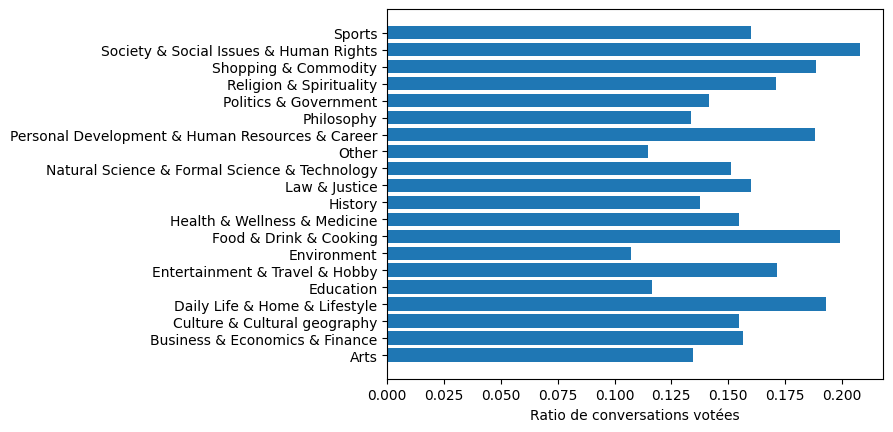

In [19]:
plt.xlabel("Ratio de conversations votées")
plt.barh(ratio.index, ratio.values)
plt.show()

A l'exception des dernières catégories, qui ne sont pas assez représentées dans la base de données conversations pour conclure, nous pouvons remarquer que certaines catégories sont plus fréquemment votées que d'autres. Par exemple, environ 20% des conversations abordant les Society & Social Issues & Human Rights ont été votées, alors que seulement 10% sur le sujet Environment le sont; c'est deux fois moins. Ce biais est donc à garder en tête, même si la plupart des catégories ont un taux de votes d'environ 15%, avec un écart-type relativement faible.

Nous pouvons observer le même type de statistiques sur les conversations en fonction de conv_turns, le nombre de dialogues dans une conversation :

In [28]:
group_conv_turns = df_conversations[df_conversations["present_in_small"]]["conv_turns"]
voted_conv_turns = group_conv_turns.value_counts()
total_conv_turns = df_conversations["conv_turns"].value_counts()
for name in voted_conv_turns.index:
    print(f"{name} : {voted_conv_turns[name]/total_conv_turns[name]} (total : {total_conv_turns[name]})")

1 : 0.134384261923741 (total : 324919)
0 : 0.17441697527774996 (total : 49955)
2 : 0.15119225037257825 (total : 53680)
3 : 0.15401236118788 (total : 19901)
4 : 0.1573748902546093 (total : 9112)
5 : 0.1344689378757515 (total : 4990)
6 : 0.1287163343826513 (total : 2859)
7 : 0.1266560678325384 (total : 1887)
8 : 0.13000817661488143 (total : 1223)
9 : 0.1322314049586777 (total : 847)
10 : 0.12941176470588237 (total : 595)
11 : 0.11791383219954649 (total : 441)
12 : 0.11641791044776119 (total : 335)
13 : 0.0989010989010989 (total : 273)
15 : 0.10050251256281408 (total : 199)
16 : 0.14634146341463414 (total : 123)
14 : 0.09183673469387756 (total : 196)
17 : 0.09701492537313433 (total : 134)
20 : 0.14705882352941177 (total : 68)
19 : 0.07228915662650602 (total : 83)
18 : 0.07407407407407407 (total : 81)
28 : 0.1875 (total : 16)
24 : 0.08571428571428572 (total : 35)
35 : 0.2727272727272727 (total : 11)
34 : 0.1 (total : 10)
29 : 0.058823529411764705 (total : 17)
48 : 0.2 (total : 5)
31 : 0.06

In [29]:
voted_conv_turns = voted_conv_turns[total_conv_turns > 100]
total_conv_turns = total_conv_turns[total_conv_turns > 100]
ratio = voted_conv_turns/total_conv_turns
print(f"Max : {max(ratio)}")
print(f"Min : {min(ratio)}")
print(f"Mean : {(ratio).mean()}")
print(f"Standard deviation : {(ratio).std()}")

Max : 0.17441697527774996
Min : 0.09183673469387756
Mean : 0.12898899460998933
Standard deviation : 0.02270811258437638


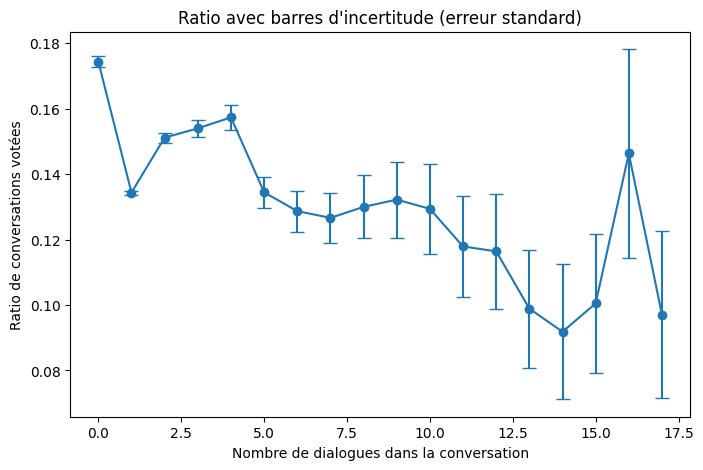

In [30]:
ratio = (voted_conv_turns / total_conv_turns).sort_index(ascending=False)
n = total_conv_turns.sort_index(ascending=False)

# erreur standard
se = np.sqrt(ratio * (1 - ratio) / n)

plt.figure(figsize=(8,5))
plt.errorbar(
    ratio.index,
    ratio.values,
    yerr=se.values,
    fmt='o-',
    capsize=5
)

plt.xlabel("Nombre de dialogues dans la conversation")
plt.ylabel("Ratio de conversations votées")
plt.title("Ratio avec barres d'incertitude (erreur standard)")
plt.show()

On note que les conversations avec plus de dialogues ont tendance à être (en général) moins votées. Cette caractéristique intoduit donc également du biais.

Finalement, regardons s'il existe aussi du biais par rapport au nombre de tokens dans la sortie des modèles :

In [4]:
group_conv_a_total_output_tokens = df_conversations[df_conversations["present_in_small"]]["total_conv_a_output_tokens"]
voted_conv_a_total_output_tokens = group_conv_a_total_output_tokens.value_counts()
total_conv_a_total_output_tokens = df_conversations["total_conv_a_output_tokens"].value_counts()
for name in voted_conv_a_total_output_tokens.index:
    print(f"{name} : {voted_conv_a_total_output_tokens[name]/total_conv_a_total_output_tokens[name]} (total : {total_conv_a_total_output_tokens[name]})")

0 : 0.13927417822534677 (total : 63156)
11 : 0.18386714116251482 (total : 843)
449 : 0.303125 (total : 320)
418 : 0.2908496732026144 (total : 306)
513 : 0.27129337539432175 (total : 317)
512 : 0.273015873015873 (total : 315)
641 : 0.29328621908127206 (total : 283)
451 : 0.2647058823529412 (total : 306)
611 : 0.2709030100334448 (total : 299)
597 : 0.25 (total : 312)
493 : 0.24522292993630573 (total : 314)
495 : 0.24600638977635783 (total : 313)
467 : 0.2576271186440678 (total : 295)
385 : 0.2245508982035928 (total : 334)
392 : 0.2516778523489933 (total : 298)
442 : 0.2525597269624573 (total : 293)
582 : 0.25524475524475526 (total : 286)
492 : 0.24829931972789115 (total : 294)
672 : 0.22955974842767296 (total : 318)
563 : 0.2589928057553957 (total : 278)
468 : 0.22929936305732485 (total : 314)
642 : 0.27169811320754716 (total : 265)
494 : 0.23529411764705882 (total : 306)
516 : 0.24573378839590443 (total : 293)
676 : 0.21492537313432836 (total : 335)
445 : 0.2099125364431487 (total : 343

In [5]:
voted_conv_a_total_output_tokens = voted_conv_a_total_output_tokens[total_conv_a_total_output_tokens > 100]
total_conv_a_total_output_tokens = total_conv_a_total_output_tokens[total_conv_a_total_output_tokens > 100]
ratio = voted_conv_a_total_output_tokens/total_conv_a_total_output_tokens
print(f"Max : {max(ratio)}")
print(f"Min : {min(ratio)}")
print(f"Mean : {(ratio).mean()}")
print(f"Standard deviation : {(ratio).std()}")

Max : 0.303125
Min : 0.025
Mean : 0.1562364959474054
Standard deviation : 0.04645406665362206


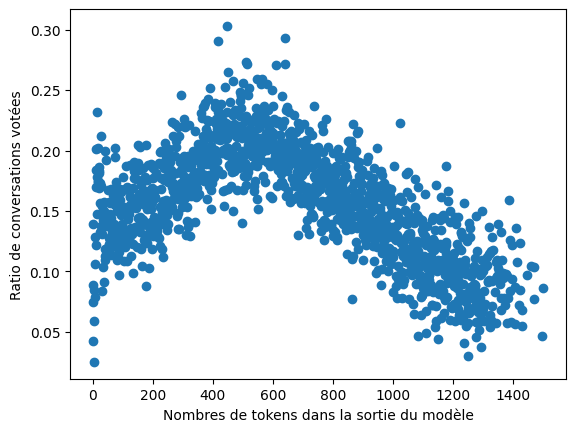

In [9]:
ratio = (voted_conv_a_total_output_tokens / total_conv_a_total_output_tokens).sort_index(ascending=False)
plt.xlabel("Nombres de tokens dans la sortie du modèle")
plt.ylabel("Ratio de conversations votées")
plt.plot(ratio, linestyle='', marker="o")


Comme visible sur le graphe, le nombre de tokens dans la sortie du modèle est aussi source de biais : la proportion de réponses suit (de façon bruitée) le nombre de tokens total dans la sortie de la conversation a, avec un maximum autour des 500-600 tokens